# Survey Patterns: Cross and Boustrophedon

Two observation patterns are used, one per supercell type:

| Type | Pattern | Score |
|------|---------|-------|
| Circular (TPV) | Two perpendicular crossing legs through the cell centre | `w_k` (fixed) |
| Elliptical (jet deformation) | `n` parallel legs in a boustrophedon (lawnmower) scan | `w_k × coverage fraction` |

**Survey distance precomputation:** each cell's best configuration (maximising score
subject to starting/ending at its centre) is precomputed once. This decouples internal
geometry from the inter-cell routing, so the orienteering solver only handles a
transit matrix between cell centres.

Run `00_simulation_data.ipynb` first to generate `data/scenario_N6_seed42.pkl`.


In [1]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import time, itertools
from dataclasses import dataclass, field
from typing import List, Optional
from math import cos, sin, sqrt, pi, radians, degrees
from scipy.optimize import milp as sp_milp, LinearConstraint, Bounds
from scipy.sparse import csr_matrix

np.set_printoptions(precision=3, suppress=True)

# ── Geometry utilities ────────────────────────────────────────────────────
def uvec(a): return np.array([cos(a), sin(a)])
def rot2d(a):
    c,s=cos(a),sin(a); return np.array([[c,-s],[s,c]])
def cross2d(v,w): return float(v[0]*w[1]-v[1]*w[0])
def ensure_ccw(verts):
    pts=[np.asarray(v,float) for v in verts]
    area2=sum(pts[i][0]*pts[(i+1)%len(pts)][1]-pts[(i+1)%len(pts)][0]*pts[i][1]
              for i in range(len(pts)))
    return pts if area2>0 else pts[::-1]
def segments_intersect(p1,p2,p3,p4):
    EPS=1e-9; d1,d2=p2-p1,p4-p3; denom=cross2d(d1,d2)
    if abs(denom)<EPS: return False
    diff=p3-p1; t=cross2d(diff,d2)/denom; u=cross2d(diff,d1)/denom
    return EPS<t<1-EPS and EPS<u<1-EPS
def point_in_poly(pt,verts):
    EPS=1e-9
    for i in range(len(verts)):
        if cross2d(verts[(i+1)%len(verts)]-verts[i],pt-verts[i])<=EPS: return False
    return True
def seg_blocked(p1,p2,verts):
    for i in range(len(verts)):
        if segments_intersect(p1,p2,verts[i],verts[(i+1)%len(verts)]): return True
    return point_in_poly(0.5*(p1+p2),verts)
def path_len(w): return sum(np.linalg.norm(w[i+1]-w[i]) for i in range(len(w)-1))
def obs_free(start,end,verts):
    s,e=np.asarray(start,float),np.asarray(end,float)
    verts=[np.asarray(v,float) for v in verts]
    ok=lambda a,b: not seg_blocked(a,b,verts)
    if ok(s,e): return [s,e]
    n=len(verts); best,bd=None,float('inf')
    for v in verts:
        if ok(s,v) and ok(v,e):
            d=np.linalg.norm(v-s)+np.linalg.norm(e-v)
            if d<bd: bd,best=d,[s,v,e]
    for si in range(n):
        for ln in range(1,n):
            for arc in [[verts[(si+k)%n] for k in range(ln+1)],
                        [verts[(si-k)%n] for k in range(ln+1)]]:
                c=[s]+arc+[e]
                if all(ok(c[k],c[k+1]) for k in range(len(c)-1)):
                    d=path_len(c)
                    if d<bd: bd,best=d,c
    return best or [s,e]
def multi_obs(start,end,obstacles):
    if not obstacles: return [np.asarray(start,float),np.asarray(end,float)]
    cur=[np.asarray(start,float),np.asarray(end,float)]
    for obs in obstacles:
        obs=[np.asarray(v,float) for v in obs]; nw=[cur[0]]
        for i in range(len(cur)-1): nw.extend(obs_free(cur[i],cur[i+1],obs)[1:])
        cur=nw
    return cur
def transit_dist(p, q, obstacles):
    return path_len(multi_obs(p, q, obstacles))
print('Geometry utilities loaded.')


Geometry utilities loaded.


In [2]:
@dataclass
class CircularSupercell:
    center:np.ndarray; radius:float; L_max:float; weight:float; name:str
    sensitivity_points:List[np.ndarray]=field(default_factory=list)
    obstacle:Optional[List[np.ndarray]]=None
    def __post_init__(self):
        self.center=np.asarray(self.center,float)
        self.sensitivity_points=[np.asarray(s,float) for s in self.sensitivity_points]
        if self.obstacle is not None:
            self.obstacle=ensure_ccw([np.asarray(v,float) for v in self.obstacle])
    def cross_endpoints(self,theta,L):
        u1,u2=uvec(theta),uvec(theta+pi/2)
        return self.center-L*u1,self.center+L*u1,self.center-L*u2,self.center+L*u2
    def cross_blocked(self,theta,L):
        if self.obstacle is None: return False
        P0,P1,P2,P3=self.cross_endpoints(theta,L); c=self.center
        return any(seg_blocked(c,p,self.obstacle) for p in [P0,P1,P2,P3])

@dataclass
class EllipticalSupercell:
    center:np.ndarray; a:float; b:float; phi:float; weight:float; name:str
    obstacle:Optional[List[np.ndarray]]=None
    def __post_init__(self):
        self.center=np.asarray(self.center,float); self._R=rot2d(self.phi)
        if self.obstacle is not None:
            self.obstacle=ensure_ccw([np.asarray(v,float) for v in self.obstacle])
    def to_world(self,e): return self.center+self._R@np.asarray(e,float)
    def leg_halflen(self,xp,dt):
        if abs(xp)>=self.a: return None
        return self.b*sqrt(max(0.,1.-(xp/self.a)**2))+dt
    def leg_endpoints(self,xp,dt):
        L=self.leg_halflen(xp,dt)
        if L is None: return None
        return self.to_world(np.array([xp,-L])),self.to_world(np.array([xp,L]))
    def leg_positions(self,n,s): return [-(n-1)*s/2.+i*s for i in range(n)]
    def legs_valid(self,n,s): return all(abs(xp)<self.a for xp in self.leg_positions(n,s))

def compute_coverage(cell,xps,sw,gr=2.,ob=0.5):
    xa=np.arange(-cell.a-gr,cell.a+gr+0.1,gr); ya=np.arange(-cell.b-gr,cell.b+gr+0.1,gr)
    XX,YY=np.meshgrid(xa,ya); ins=(XX/cell.a)**2+(YY/cell.b)**2<=1.
    xp=np.array(xps,float); dx=np.abs(XX[:,:,None]-xp[None,None,:]); cov=(dx<=sw).sum(axis=2)
    ca=gr**2; cv=float((ins&(cov>=1)).sum()*ca); ov=float((ins*np.maximum(0,cov-1)).sum()*ca)
    return cv,ov
print('Dataclasses and coverage loaded.')


Dataclasses and coverage loaded.


In [3]:
def route_circ_from(start, cell, theta, L, all_obs):
    """Optimal ordering: cross arms and sensitivity points in any order/direction.
    Returns (dist, exit_pt)."""
    s = np.asarray(start, float)
    P0, P1, P2, P3 = cell.cross_endpoints(theta, L)
    c = np.asarray(cell.center, float)
    # Each task: list of (entry, [internal_wpts], exit) options
    # Arms reversible; sensitivity points have a single option
    arm1 = [(P0, [c, P1], P1), (P1, [c, P0], P0)]
    arm2 = [(P2, [c, P3], P3), (P3, [c, P2], P2)]
    task_opts = [arm1, arm2] + [[(sp, [], sp)] for sp in cell.sensitivity_points]
    n = len(task_opts)
    best_d, best_pos = float('inf'), s
    for perm in itertools.permutations(range(n)):
        for choices in itertools.product(*[task_opts[i] for i in perm]):
            pos = s.copy(); d = 0.
            for (entry, wpts, exit_pt) in choices:
                entry = np.asarray(entry, float)
                tr = multi_obs(pos, entry, all_obs); d += path_len(tr); pos = entry
                for wp in wpts:
                    wp = np.asarray(wp, float); d += np.linalg.norm(wp - pos); pos = wp
                pos = np.asarray(exit_pt, float)
            if d < best_d: best_d, best_pos = d, pos.copy()
    return best_d, best_pos

def route_ellip_from(start, cell, n, s, dt, rev, etop, all_obs):
    """Boustrophedon scan from start. Returns (dist, exit_pt)."""
    s_=np.asarray(start,float)
    ordered=list(reversed(cell.leg_positions(n,s))) if rev else cell.leg_positions(n,s)
    legs=[]
    for xp in ordered:
        ep=cell.leg_endpoints(xp,dt)
        if ep is None: return float('inf'),s_
        legs.append(ep)
    dist=0.; pos=s_.copy()
    for i,(bot,top) in enumerate(legs):
        gu=(i%2==0)!=etop; ep_,ex=(bot,top) if gu else (top,bot)
        tr=multi_obs(pos,ep_,all_obs); dist+=path_len(tr); pos=tr[-1]
        dist+=np.linalg.norm(ex-pos); pos=ex.copy()
    return dist,pos

def precompute_cell(cell, all_obs, start_pt,
                    theta_grid, L_grid, sw, dt, s_min, n_max, n_s_steps,
                    overlap_bonus=0.5):
    """Enumerate all survey configurations. Returns list of dicts."""
    configs = []
    if isinstance(cell, CircularSupercell):
        for theta in theta_grid:
            for L in L_grid:
                if L > cell.L_max: continue
                if cell.cross_blocked(theta, L): continue
                d, exit_pt = route_circ_from(start_pt, cell, theta, L, all_obs)
                if d < float('inf'):
                    configs.append(dict(score=cell.weight, survey_dist=d, exit_pt=exit_pt,
                                        params=dict(theta=theta, L=L), cell_type='circ'))
    else:
        ellip_ref = pi * cell.a * cell.b
        for n in range(1, n_max+1):
            sl = ([0.] if n == 1
                  else ([] if 2.*cell.a/(n-1)*0.999 < s_min
                        else list(np.linspace(s_min, 2.*cell.a/(n-1)*0.999, n_s_steps))))
            for s in sl:
                if not cell.legs_valid(n, s): continue
                xps = cell.leg_positions(n, s)
                cv, ov = compute_coverage(cell, xps, sw)
                sc = cell.weight * (cv + overlap_bonus * ov) / ellip_ref
                for rev in [False, True]:
                    for etop in [False, True]:
                        d, exit_pt = route_ellip_from(start_pt, cell, n, s, dt, rev, etop, all_obs)
                        if d < float('inf'):
                            configs.append(dict(score=sc, survey_dist=d, exit_pt=exit_pt,
                                                params=dict(n=n, s=float(s), rev=rev, etop=etop),
                                                cell_type='ellip'))
    return configs
print('Survey route helpers loaded.')


Survey route helpers loaded.


In [4]:
# ── Load scenario + precompute ────────────────────────────────────────────
import pickle, time
with open('data/scenario_N6_seed42.pkl', 'rb') as f:
    s = pickle.load(f)
BASE=s['BASE']; OBSTACLES=s['OBSTACLES']; ALL_CELLS=s['cells']
labels=s['labels']; N_CELLS=s['N_CELLS']
valid_cells = list(range(1, N_CELLS+1))

THETA_GRID = np.radians(np.arange(0, 180, 15))
L_GRID     = np.array([35., 50., 65., 80.])
SW=12.; DT=8.; S_MIN=18.; N_MAX=6; N_S_STEPS=10; OVERLAP_BONUS=0.5

t0 = time.time()
cell_configs = [precompute_cell(cell, OBSTACLES, cell.center,
                                THETA_GRID, L_GRID, SW, DT, S_MIN, N_MAX, N_S_STEPS, OVERLAP_BONUS)
                for cell in ALL_CELLS]
best_cfg_idx = {k: max(range(len(cell_configs[k-1])),
                       key=lambda i: (cell_configs[k-1][i]['score'],
                                      -cell_configs[k-1][i]['survey_dist']))
               for k in range(1, N_CELLS+1)}
print(f'Precomputed in {time.time()-t0:.2f}s')
print()
print(f"  {'Cell':>4}  {'Type':>10}  {'Weight':>6}  {'Best score':>10}  {'Survey dist':>11}  {'# configs':>9}")
print('  ' + '-'*62)
for k in range(1, N_CELLS+1):
    cell = ALL_CELLS[k-1]; cfg = cell_configs[k-1][best_cfg_idx[k]]
    ctype = 'Circular' if isinstance(cell, CircularSupercell) else 'Elliptical'
    print(f"  {labels[k]:>4}  {ctype:>10}  {cell.weight:>6.1f}  {cfg['score']:>10.4f}"
          f"  {cfg['survey_dist']:>11.1f}  {len(cell_configs[k-1]):>9d}")


Precomputed in 6.91s

  Cell        Type  Weight  Best score  Survey dist  # configs
  --------------------------------------------------------------
    C1    Circular     1.8      1.8000        249.2         30
    C2    Circular     3.0      3.0000        236.6         36
    C3    Circular     2.0      2.0000        240.4         48
    E1  Elliptical     3.5      4.1829        555.0        204
    E2  Elliptical     2.5      2.9353        438.1        204
    E3  Elliptical     2.0      2.3000        460.3        204


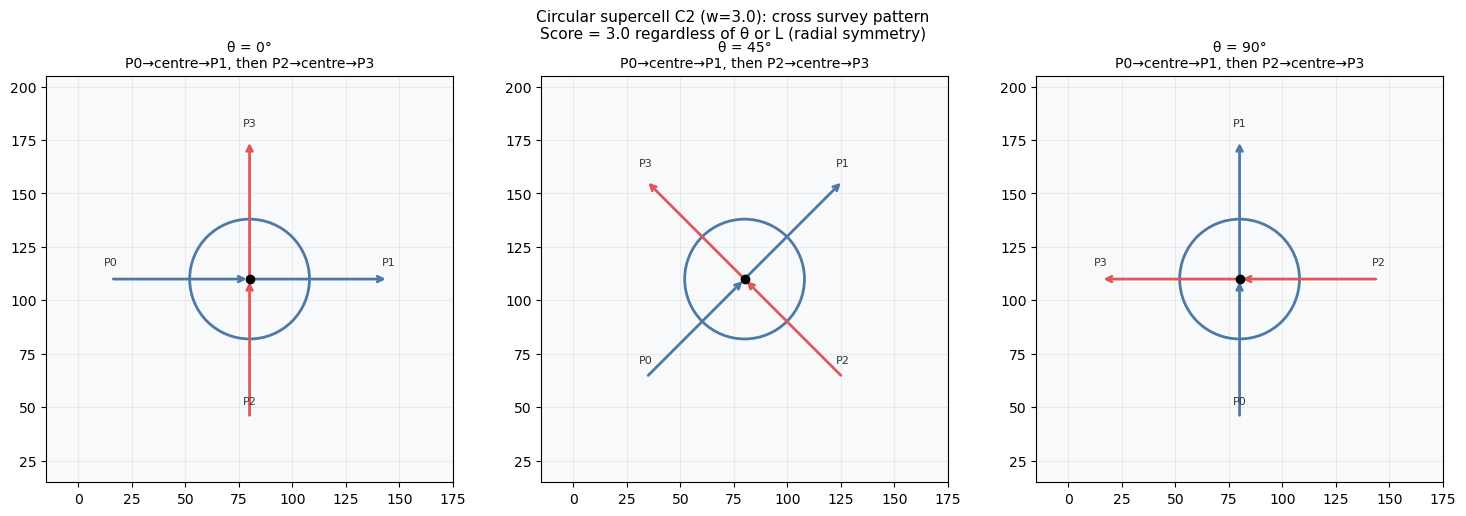

Circular cross pattern: P0→centre→P1 (arm 1), P2→centre→P3 (arm 2)
Score = weight = 3.0 (constant, no θ or L dependence)
Figure saved → figures/circular_pattern_demo.png


In [5]:
# ── Circular survey: cross pattern at 3 different θ ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cell = ALL_CELLS[1]   # C2 — highest-weight circular cell

for ax, th_deg in zip(axes, [0, 45, 90]):
    th = radians(th_deg)
    P0, P1, P2, P3 = cell.cross_endpoints(th, 65.)
    ax.set_facecolor('#f8f9fa')
    ax.add_patch(plt.Circle(cell.center, cell.radius,
                            fill=False, edgecolor='#4e79a7', lw=2, zorder=3))
    # Arm 1: P0 → centre → P1
    ax.annotate('', xy=cell.center, xytext=P0,
                arrowprops=dict(arrowstyle='->', color='#4e79a7', lw=2))
    ax.annotate('', xy=P1, xytext=cell.center,
                arrowprops=dict(arrowstyle='->', color='#4e79a7', lw=2))
    # Arm 2: P2 → centre → P3
    ax.annotate('', xy=cell.center, xytext=P2,
                arrowprops=dict(arrowstyle='->', color='#e15759', lw=2))
    ax.annotate('', xy=P3, xytext=cell.center,
                arrowprops=dict(arrowstyle='->', color='#e15759', lw=2))
    ax.plot(*cell.center, 'ko', ms=6, zorder=5)
    for pt, lbl in zip([P0,P1,P2,P3],['P0','P1','P2','P3']):
        ax.annotate(lbl, pt, fontsize=8, ha='center',
                    xytext=(0, 10), textcoords='offset points', color='#333')
    ax.set_xlim(cell.center[0]-95, cell.center[0]+95)
    ax.set_ylim(cell.center[1]-95, cell.center[1]+95)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    ax.set_title(f'θ = {th_deg}°\nP0→centre→P1, then P2→centre→P3', fontsize=10)

plt.suptitle(f'Circular supercell {cell.name} (w={cell.weight}): cross survey pattern\n'
             f'Score = {cell.weight:.1f} regardless of θ or L (radial symmetry)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/circular_pattern_demo.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('Circular cross pattern: P0→centre→P1 (arm 1), P2→centre→P3 (arm 2)')
print(f'Score = weight = {cell.weight} (constant, no θ or L dependence)')
print('Figure saved → figures/circular_pattern_demo.png')


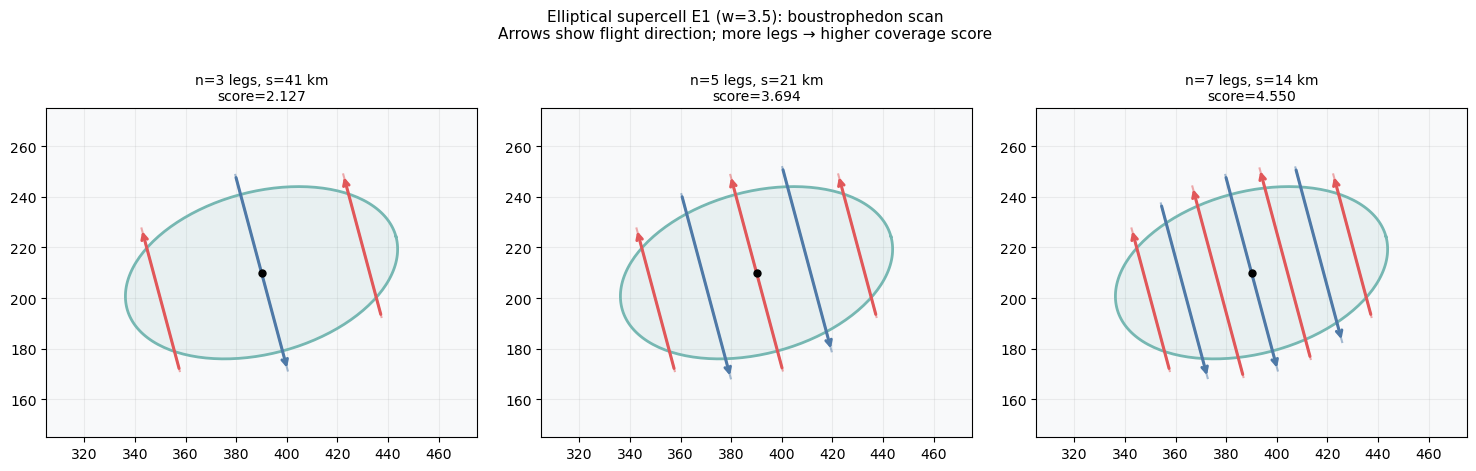

Elliptical boustrophedon: alternating-direction parallel legs.
More legs → better coverage → higher score, but also longer survey distance.
Figure saved → figures/elliptical_pattern_demo.png


In [6]:
# ── Elliptical survey: boustrophedon at 3 different leg counts ────────────
cell = ALL_CELLS[3]   # E1 — highest-weight elliptical cell
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n_legs in zip(axes, [3, 5, 7]):
    s_val = min(1.5*cell.a/max(n_legs-1,1), 2.*cell.a/(n_legs-1)*0.95) if n_legs>1 else 0.
    xps = cell.leg_positions(n_legs, s_val)
    ax.set_facecolor('#f8f9fa')
    th = np.linspace(0, 2*pi, 200)
    R_ = np.array([[cos(cell.phi),-sin(cell.phi)],[sin(cell.phi),cos(cell.phi)]])
    pts = (R_ @ np.vstack([cell.a*np.cos(th), cell.b*np.sin(th)])).T + cell.center
    ax.fill(pts[:,0], pts[:,1], color='#76b7b2', alpha=0.12, zorder=2)
    ax.plot(pts[:,0], pts[:,1], color='#76b7b2', lw=2, zorder=3)
    for i, xp in enumerate(xps):
        ep = cell.leg_endpoints(xp, DT)
        if ep is None: continue
        bot, top = ep
        col = '#e15759' if i%2==0 else '#4e79a7'
        start, end = (bot, top) if i%2==0 else (top, bot)
        ax.annotate('', xy=end, xytext=start,
                    arrowprops=dict(arrowstyle='->', color=col, lw=2.2), zorder=4)
        ax.plot([bot[0],top[0]], [bot[1],top[1]], color=col, lw=1.5, alpha=0.5, zorder=3)
    ax.plot(*cell.center, 'ko', ms=5, zorder=6)
    ax.set_xlim(cell.center[0]-85, cell.center[0]+85)
    ax.set_ylim(cell.center[1]-65, cell.center[1]+65)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
    cv, ov = compute_coverage(cell, xps, SW)
    sc = cell.weight*(cv + OVERLAP_BONUS*ov)/(pi*cell.a*cell.b)
    ax.set_title(f'n={n_legs} legs, s={s_val:.0f} km\nscore={sc:.3f}', fontsize=10)

plt.suptitle(f'Elliptical supercell {cell.name} (w={cell.weight}): boustrophedon scan\n'
             f'Arrows show flight direction; more legs → higher coverage score', fontsize=11)
plt.tight_layout()
plt.savefig('figures/elliptical_pattern_demo.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('Elliptical boustrophedon: alternating-direction parallel legs.')
print('More legs → better coverage → higher score, but also longer survey distance.')
print('Figure saved → figures/elliptical_pattern_demo.png')


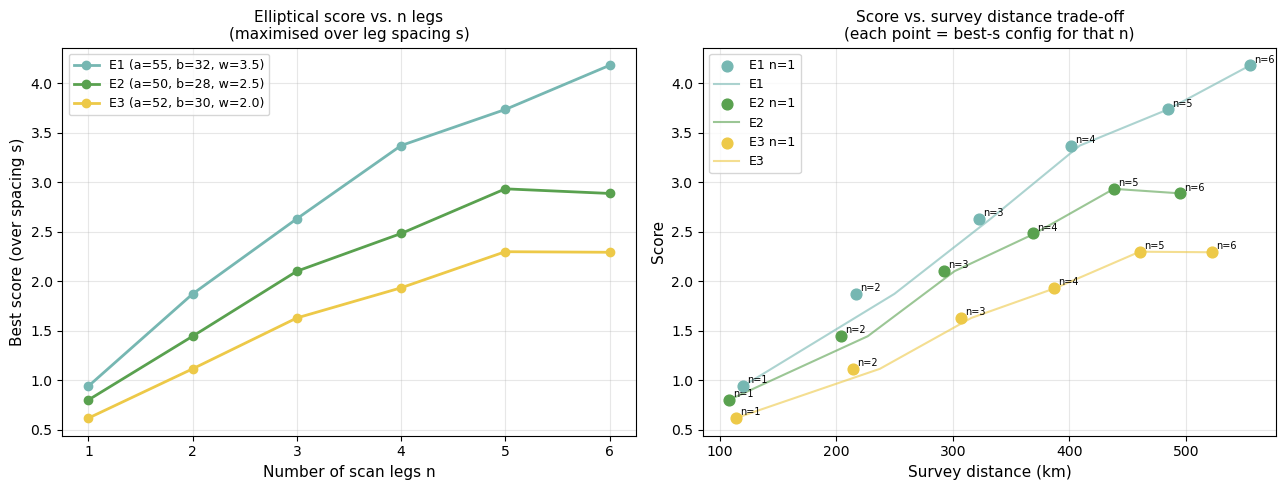

Key insight: more legs → higher score AND longer survey distance.
The orienteering solver must balance score gain vs. extra distance cost.
Figure saved → figures/score_analysis.png


In [7]:
# ── Score functions ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: score vs n_legs for all elliptical cells
ax = axes[0]
ellip_cells = [(k+1, c) for k,c in enumerate(ALL_CELLS) if isinstance(c, EllipticalSupercell)]
colors_e = ['#76b7b2','#59a14f','#edc948']
for (k, cell), col in zip(ellip_cells, colors_e):
    cfgs = cell_configs[k-1]
    scores_n = []
    for n in range(1, N_MAX+1):
        nc = [c for c in cfgs if c['params']['n']==n]
        scores_n.append(max((c['score'] for c in nc), default=0.))
    ax.plot(range(1, len(scores_n)+1), scores_n, 'o-', color=col, lw=2,
            label=f'{cell.name} (a={cell.a:.0f}, b={cell.b:.0f}, w={cell.weight})')
ax.set_xlabel('Number of scan legs n', fontsize=11)
ax.set_ylabel('Best score (over spacing s)', fontsize=11)
ax.set_title('Elliptical score vs. n legs\n(maximised over leg spacing s)', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 2: score vs survey distance trade-off
ax = axes[1]
for (k, cell), col in zip(ellip_cells, colors_e):
    cfgs = cell_configs[k-1]
    for n in range(1, N_MAX+1):
        nc = [c for c in cfgs if c['params']['n']==n]
        if nc:
            best = max(nc, key=lambda c: (c['score'], -c['survey_dist']))
            ax.scatter(best['survey_dist'], best['score'], color=col, s=60,
                       zorder=4, label=f'{cell.name} n={n}' if n==1 else '')
            ax.annotate(f'n={n}', (best['survey_dist'], best['score']),
                        fontsize=7, xytext=(3, 2), textcoords='offset points')
    # Connect points for same cell
    pts = sorted([(max(c['survey_dist'] for c in cfgs if c['params']['n']==n),
                   max(c['score'] for c in cfgs if c['params']['n']==n))
                  for n in range(1, N_MAX+1)
                  if any(c['params']['n']==n for c in cfgs)])
    ax.plot([p[0] for p in pts], [p[1] for p in pts], '-', color=col, lw=1.5, alpha=0.6,
            label=cell.name)
ax.set_xlabel('Survey distance (km)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Score vs. survey distance trade-off\n(each point = best-s config for that n)',
             fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/score_analysis.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close()
print('Key insight: more legs → higher score AND longer survey distance.')
print('The orienteering solver must balance score gain vs. extra distance cost.')
print('Figure saved → figures/score_analysis.png')
